In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimpy import clean_columns

/Users/chloecho/anaconda3/envs/cornell_dev/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
deli_cup = pd.read_csv('Data/deli_cup.csv')
deli_cup

,Container Number,Container Type,Project,Field ID,Treatment,Collection Date,Seed Type,Number Seeds,SCM Larvae Sum,SCM Pupae Sum,SCM Seed,Phorid Seed,Other Damage,Wireworms,Other Seeds,Wireworm Presence/absence,Grub presence/absence,Checked?,Ordered Entered,Notes
0,25_D_1181,DELI,R,CER_DEL_1,NEONIC,5/28/25,FIELD CORN,14.0,1,0,0,0,1,3,0,YES,YES,Y,294,NaN
1,25_D_1182,DELI,R,CER_DEL_1,FUNG,5/28/25,FIELD CORN,14.0,0,0,0,0,0,0,0,NO,NO,Y,293,NaN
2,25_D_1183,DELI,R,CER_DEL_1,NEONIC,5/28/25,FIELD CORN,17.0,2,0,0,0,0,0,0,NO,NO,Y,380,NaN
3,25_D_1184,DELI,R,CER_DEL_1,NEONIC,5/28/25,FIELD CORN,15.0,0,0,0,0,0,0,0,NO,NO,Y,308,NaN
4,25_D_1185,DELI,R,CER_DEL_1,FUNG,5/28/25,FIELD CORN,15.0,2,0,0,0,0,0,0,NO,NO,Y,51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,25_D_2513,DELI,R,ZUE_VOT,FUNG,7/4/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,712,NaN
982,25_D_2514,DELI,R,ZUE_VOT,FUNG,7/3/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,710,NaN
983,25_D_2515,DELI,R,ZUE_VOT,FUNG,7/8/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,716,NaN
984,25_D_2516,DELI,R,ZUE_VOT,FUNG,7/6/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,714,NaN


In [8]:
deli_cup['Total SCM'] = deli_cup['SCM Larvae Sum'] + deli_cup['SCM Pupae Sum']
field_deli_cup = deli_cup[(deli_cup['Seed Type'] != 'SWEET CORN') & (deli_cup['Seed Type'] != 'SNAP')]

field_deli_cup['Treatment'] = field_deli_cup['Treatment'].replace({'NEONIC': 'Treated', 'FUNG': 'Untreated'})
field_deli_cup['Seed Type'] = field_deli_cup['Seed Type'].replace({'FIELD CORN': 'Field corn', 'SOY': 'Soybean'})
field_deli_cup = field_deli_cup.rename(columns={'Seed Type': 'Crop'})

field_deli_cup['Avg SCM'] = field_deli_cup['Total SCM'] / field_deli_cup['Number Seeds']

field_deli_cup

/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_89872/789136071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  field_deli_cup['Treatment'] = field_deli_cup['Treatment'].replace({'NEONIC': 'Treated', 'FUNG': 'Untreated'})
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_89872/789136071.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  field_deli_cup['Seed Type'] = field_deli_cup['Seed Type'].replace({'FIELD CORN': 'Field corn', 'SOY': 'Soybean'})


,Container Number,Container Type,Project,Field ID,Treatment,Collection Date,Crop,Number Seeds,SCM Larvae Sum,SCM Pupae Sum,...,Other Damage,Wireworms,Other Seeds,Wireworm Presence/absence,Grub presence/absence,Checked?,Ordered Entered,Notes,Total SCM,Avg SCM
0,25_D_1181,DELI,R,CER_DEL_1,Treated,5/28/25,Field corn,14.0,1,0,...,1,3,0,YES,YES,Y,294,NaN,1,0.071429
1,25_D_1182,DELI,R,CER_DEL_1,Untreated,5/28/25,Field corn,14.0,0,0,...,0,0,0,NO,NO,Y,293,NaN,0,0.000000
2,25_D_1183,DELI,R,CER_DEL_1,Treated,5/28/25,Field corn,17.0,2,0,...,0,0,0,NO,NO,Y,380,NaN,2,0.117647
3,25_D_1184,DELI,R,CER_DEL_1,Treated,5/28/25,Field corn,15.0,0,0,...,0,0,0,NO,NO,Y,308,NaN,0,0.000000
4,25_D_1185,DELI,R,CER_DEL_1,Untreated,5/28/25,Field corn,15.0,2,0,...,0,0,0,NO,NO,Y,51,NaN,2,0.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,25_D_1158,DELI,R,STA_WOO,Untreated,5/23/25,Field corn,15.0,1,1,...,0,1,1,YES,NO,Y,15,NaN,2,0.133333
946,25_D_1159,DELI,R,STA_WOO,Treated,5/23/25,Field corn,15.0,0,0,...,0,0,0,NO,NO,Y,296,NaN,0,0.000000
947,25_D_1160,DELI,R,STA_WOO,Treated,5/23/25,Field corn,15.0,0,0,...,0,0,0,NO,NO,Y,295,NaN,0,0.000000
948,25_D_1161,DELI,R,STA_WOO,Untreated,5/23/25,Field corn,15.0,3,0,...,1,0,1,NO,NO,Y,3,NaN,3,0.200000


In [4]:
stand = pd.read_csv('Data/stand_loss.csv')
stand

,Data Collector,Field ID,Date,Sampling period,Crop,Treatment,Section number,Plant growth stage,Stand count,Notes
0,Paul Cerosaletti,CER_DEL_1,6/16/25,VE/V1,Field corn,Neonic,1,VE/V1,29.0,NaN
1,Paul Cerosaletti,CER_DEL_1,6/16/25,VE/V1,Field corn,Neonic,2,VE/V1,30.0,NaN
2,Paul Cerosaletti,CER_DEL_1,6/16/25,VE/V1,Field corn,Neonic,3,VE/V1,24.0,NaN
3,Paul Cerosaletti,CER_DEL_1,6/16/25,VE/V1,Field corn,Neonic,4,VE/V1,29.0,NaN
4,Paul Cerosaletti,CER_DEL_1,6/16/25,VE/V1,Field corn,Neonic,5,VE/V1,28.0,NaN
...,...,...,...,...,...,...,...,...,...,...
1777,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,5,V3,85.0,NaN
1778,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,6,V3,88.0,NaN
1779,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,7,V3,97.0,NaN
1780,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,8,V3,85.0,NaN


In [5]:
biomass = pd.read_csv('Data/fresh_biomass.csv')
biomass

,Data Collector,Field ID,Date,Sampling period,Crop,Treatment,Section number,Plant growth stage,Number of plants,Total weight (g),Notes,Untared weight (g)
0,Paul Cerosaletti,CER_DEL_1,6/26/25,V3/V4,Field corn,Neonic,1,V4,15,865.7,Corrected for 42.3 g bag,908.0
1,Paul Cerosaletti,CER_DEL_1,6/26/25,V3/V4,Field corn,Neonic,2,V4,15,578.7,Corrected for 42.3 g bag,621.0
2,Paul Cerosaletti,CER_DEL_1,6/26/25,V3/V4,Field corn,Neonic,3,V4,15,658.7,Corrected for 42.3 g bag,701.0
3,Paul Cerosaletti,CER_DEL_1,6/26/25,V3/V4,Field corn,Neonic,4,V4,15,818.7,Corrected for 42.3 g bag,861.0
4,Paul Cerosaletti,CER_DEL_1,6/26/25,V3/V4,Field corn,Neonic,5,V4,15,776.7,Corrected for 42.3 g bag,819.0
...,...,...,...,...,...,...,...,...,...,...,...,...
967,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,5,V3,15,110.0,NaN,NaN
968,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,6,V3,15,114.0,NaN,NaN
969,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,7,V3,15,126.0,NaN,NaN
970,Mike Hunter,HUN_REE,6/23/25,V3/V4,Soybean,Fung,8,V3,15,131.0,NaN,NaN


In [6]:
silage_yield = pd.read_csv('Data/silage_yield.csv')
silage_yield

,Data Collector,Field ID,Date,Sampling period,Crop,Grain or Silage,Treatment,Yield (tons/acre),Yield (dry matter)
0,Natika Walters,KUH_COL,9/17/2025,Harvest,Field corn,Silage,Neonic,18.700,6.73
1,Natika Walters,KUH_COL,9/17/2025,Harvest,Field corn,Silage,Fung,18.500,6.43
2,Katelyn Miller,MIL_CRO_2,9/22/2025,Harvest,Field corn,Silage,Neonic,20.270,6.75
3,Katelyn Miller,MIL_CRO_2,9/22/2025,Harvest,Field corn,Silage,Fung,18.350,7.32
4,Katelyn Miller,MIL_CRO_1,9/22/2025,Harvest,Field corn,Silage,Neonic,30.610,9.00
5,Katelyn Miller,MIL_CRO_1,9/22/2025,Harvest,Field corn,Silage,Fung,27.920,8.51
6,Erik Smith,SMI_LAT,10/15/2025,Harvest,Field corn,Silage,Neonic,15.770,6.49
7,Erik Smith,SMI_LAT,10/15/2025,Harvest,Field corn,Silage,Fung,17.233,6.42
8,Jodi Letham,LET_STE,9/29/2025,Harvest,Field corn,Silage,Neonic,12.160,4.40
9,Jodi Letham,LET_STE,9/29/2025,Harvest,Field corn,Silage,Fung,16.410,5.94


In [7]:
grain_yield = pd.read_csv('Data/grain_yield.csv')
grain_yield

,Data Collector,Field ID,Date,Sampling period,Crop,Grain or Silage,Treatment,Yield (bu/acre)
0,Janice Degni,DEG_FRI_1,11/4/2025,Harvest,Field corn,Grain,Neonic,87.0700
1,Janice Degni,DEG_FRI_1,11/4/2025,Harvest,Field corn,Grain,Fung,42.3900
2,Katelyn Miller,MIL_ZIT_2,11/7/2025,Harvest,Field corn,Grain,Neonic,118.1000
3,Katelyn Miller,MIL_ZIT_2,11/7/2025,Harvest,Field corn,Grain,Fung,93.0700
4,Katelyn Miller,MIL_ZIT_3,11/25/2025,Harvest,Field corn,Grain,Neonic,124.0000
5,Katelyn Miller,MIL_ZIT_3,11/25/2025,Harvest,Field corn,Grain,Fung,134.8000
6,Erik Smith,SMI_BUR,11/20/2025,Harvest,Field corn,Grain,Neonic,124.9200
7,Erik Smith,SMI_BUR,11/20/2025,Harvest,Field corn,Grain,Fung,119.4200
8,Erik Smith,SMI_CON_2,12/15/2025,Harvest,Field corn,Grain,Neonic,113.3700
9,Erik Smith,SMI_CON_2,12/15/2025,Harvest,Field corn,Grain,Fung,115.3200


In [ ]:
soy_yield = pd.read_csv('../Data/soybean_yield.csv')
soy_yield

,Data Collector,Field ID,Date,Sampling period,Crop,Treatment,Yield (bu/acre)
0,Katelyn Miller,MIL_COB,10/17/2025,Harvest,Soybean,Neonic,57.50
1,Katelyn Miller,MIL_COB,10/17/2025,Harvest,Soybean,Fung,54.70
2,Erik Smith,SMI_ARN_2,10/27/2025,Harvest,Soybean,Neonic,32.52
3,Erik Smith,SMI_ARN_2,10/27/2025,Harvest,Soybean,Fung,33.81
4,Janice Degni,DEG_LAF_2,10/15/2025,Harvest,Soybean,Neonic,50.99
5,Janice Degni,DEG_LAF_2,10/15/2025,Harvest,Soybean,Fung,42.18
6,Mike Stanyard,STA_FRE,10/6/2025,Harvest,Soybean,Neonic,35.70
7,Mike Stanyard,STA_FRE,10/6/2025,Harvest,Soybean,Fung,40.26
8,Mike Stanyard,STA_REE_2,9/30/2025,Harvest,Soybean,Neonic,48.43
9,Mike Stanyard,STA_REE_2,9/30/2025,Harvest,Soybean,Fung,57.79


In [20]:
field_corn_deli_cup = field_deli_cup.loc[field_deli_cup['Crop'] == 'Field corn']
field_corn_deli_cup = field_corn_deli_cup.groupby(['Field ID', 'Treatment'])['Avg SCM'].agg([np.mean])
field_corn_deli_cup = field_corn_deli_cup.reset_index()
field_corn_deli_cup_pivot = field_corn_deli_cup.pivot(index='Field ID', columns= 'Treatment', values= ['mean'])
field_corn_deli_cup_pivot['Diff'] = field_corn_deli_cup_pivot['mean']['Treated'] - field_corn_deli_cup_pivot['mean']['Untreated']
field_corn_deli_cup_pivot = field_corn_deli_cup_pivot.reset_index().sort_values('Diff')
field_corn_deli_cup_pivot.columns = [''.join(col).strip() for col in field_corn_deli_cup_pivot.columns.values]

field_corn_deli_cup_se = pd.DataFrame(field_deli_cup.loc[field_deli_cup['Crop'] == 'Field corn'].groupby('Field ID')['Avg SCM'].agg(np.std))
field_corn_deli_cup_se = field_corn_deli_cup_se.reset_index().rename(columns={'Avg SCM': 'std'})

field_corn_deli_cup_pivot = field_corn_deli_cup_pivot.merge(field_corn_deli_cup_se, on='Field ID')

field_corn_deli_cup_pivot

/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_89872/3980512053.py:2: FutureWarning: The provided callable <function mean at 0x105f01440> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  field_corn_deli_cup = field_corn_deli_cup.groupby(['Field ID', 'Treatment'])['Avg SCM'].agg([np.mean])
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_89872/3980512053.py:9: FutureWarning: The provided callable <function std at 0x105f01580> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  field_corn_deli_cup_se = pd.DataFrame(field_deli_cup.loc[field_deli_cup['Crop'] == 'Field corn'].groupby('Field ID')['Avg SCM'].agg(np.std))


,Field ID,meanTreated,meanUntreated,Diff,std
0,STA_WOO,0.000000,0.246032,-0.246032,0.178923
1,SMI_LAT,0.024501,0.101961,-0.077459,0.090383
2,KUH_COL,0.025000,0.094907,-0.069907,0.120418
3,SMI_HOF_1,0.000000,0.066667,-0.066667,0.141421
4,LET_MAC,0.048366,0.111111,-0.062745,0.115137
5,LET_VER,0.196759,0.229630,-0.032870,0.298136
6,LET_STE_2,0.007407,0.036410,-0.029003,0.042916
7,MIL_ZIT_3,0.000000,0.028571,-0.028571,0.048507
8,STA_KRE,0.044444,0.069717,-0.025272,0.084433
9,CER_DEL_1,0.028416,0.051852,-0.023436,0.085158


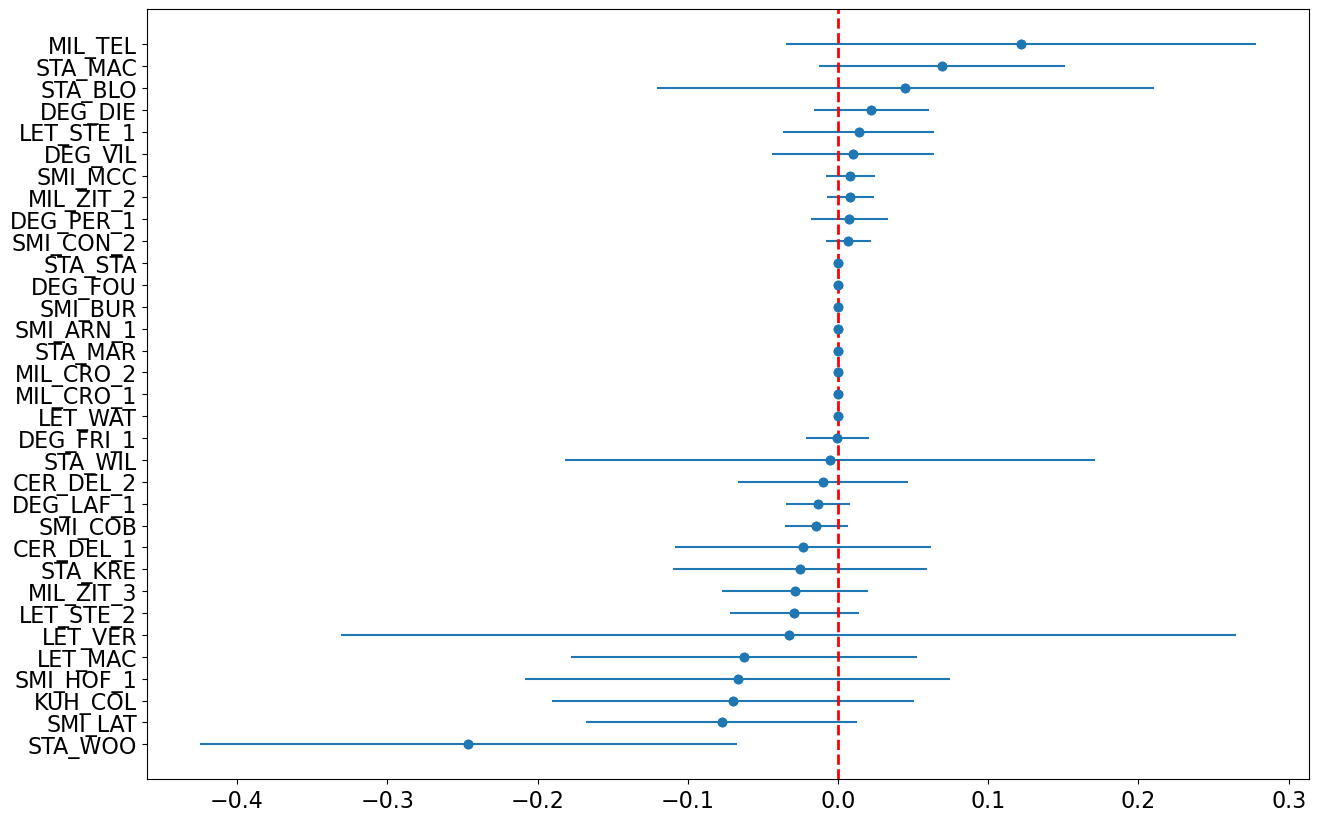

In [21]:
plt.figure(figsize=(15,10))
plt.rcParams.update({'font.size': 16})

plt.scatter(field_corn_deli_cup_pivot['Diff'], field_corn_deli_cup_pivot['Field ID'])
plt.errorbar(field_corn_deli_cup_pivot['Diff'], field_corn_deli_cup_pivot['Field ID'], xerr=field_corn_deli_cup_pivot['std'], fmt="o")
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)


In [23]:
soy_deli_cup = field_deli_cup.loc[field_deli_cup['Crop'] == 'Soybean']
soy_deli_cup = soy_deli_cup.groupby(['Field ID', 'Treatment'])['Avg SCM'].agg([np.mean])
soy_deli_cup = soy_deli_cup.reset_index()
soy_deli_cup_pivot = soy_deli_cup.pivot(index='Field ID', columns= 'Treatment', values= ['mean'])
soy_deli_cup_pivot['Diff'] = soy_deli_cup_pivot['mean']['Treated'] - soy_deli_cup_pivot['mean']['Untreated']
soy_deli_cup_pivot = soy_deli_cup_pivot.reset_index().sort_values('Diff')
soy_deli_cup_pivot.columns = [''.join(col).strip() for col in soy_deli_cup_pivot.columns.values]

soy_deli_cup_se = pd.DataFrame(field_deli_cup.loc[field_deli_cup['Crop'] == 'Soybean'].groupby('Field ID')['Avg SCM'].agg(np.std))
soy_deli_cup_se = soy_deli_cup_se.reset_index().rename(columns={'Avg SCM': 'std'})

soy_deli_cup_pivot = soy_deli_cup_pivot.merge(soy_deli_cup_se, on='Field ID')

soy_deli_cup_pivot

/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_89872/3212637239.py:2: FutureWarning: The provided callable <function mean at 0x105f01440> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  soy_deli_cup = soy_deli_cup.groupby(['Field ID', 'Treatment'])['Avg SCM'].agg([np.mean])
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_89872/3212637239.py:9: FutureWarning: The provided callable <function std at 0x105f01580> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  soy_deli_cup_se = pd.DataFrame(field_deli_cup.loc[field_deli_cup['Crop'] == 'Soybean'].groupby('Field ID')['Avg SCM'].agg(np.std))


,Field ID,meanTreated,meanUntreated,Diff,std
0,DEG_PER_2,0.267791,0.462212,-0.194421,0.352245
1,SMI_DOU,0.116484,0.250926,-0.134442,0.182995
2,HUN_REE,0.007407,0.093519,-0.086111,0.077989
3,SMI_ARN_2,0.000000,0.057579,-0.057579,0.110826
4,MIL_COB,0.000000,0.027544,-0.027544,0.043945
5,SMI_CON_1,0.007407,0.029630,-0.022222,0.050127
6,MIL_ZIT_1,0.000000,0.021351,-0.021351,0.024612
7,CHO_GEN,0.014815,0.025000,-0.010185,0.039191
8,SMI_HOF_2,0.000000,0.007407,-0.007407,0.015713
9,DEG_LAF_2,0.000000,0.006944,-0.006944,0.015158


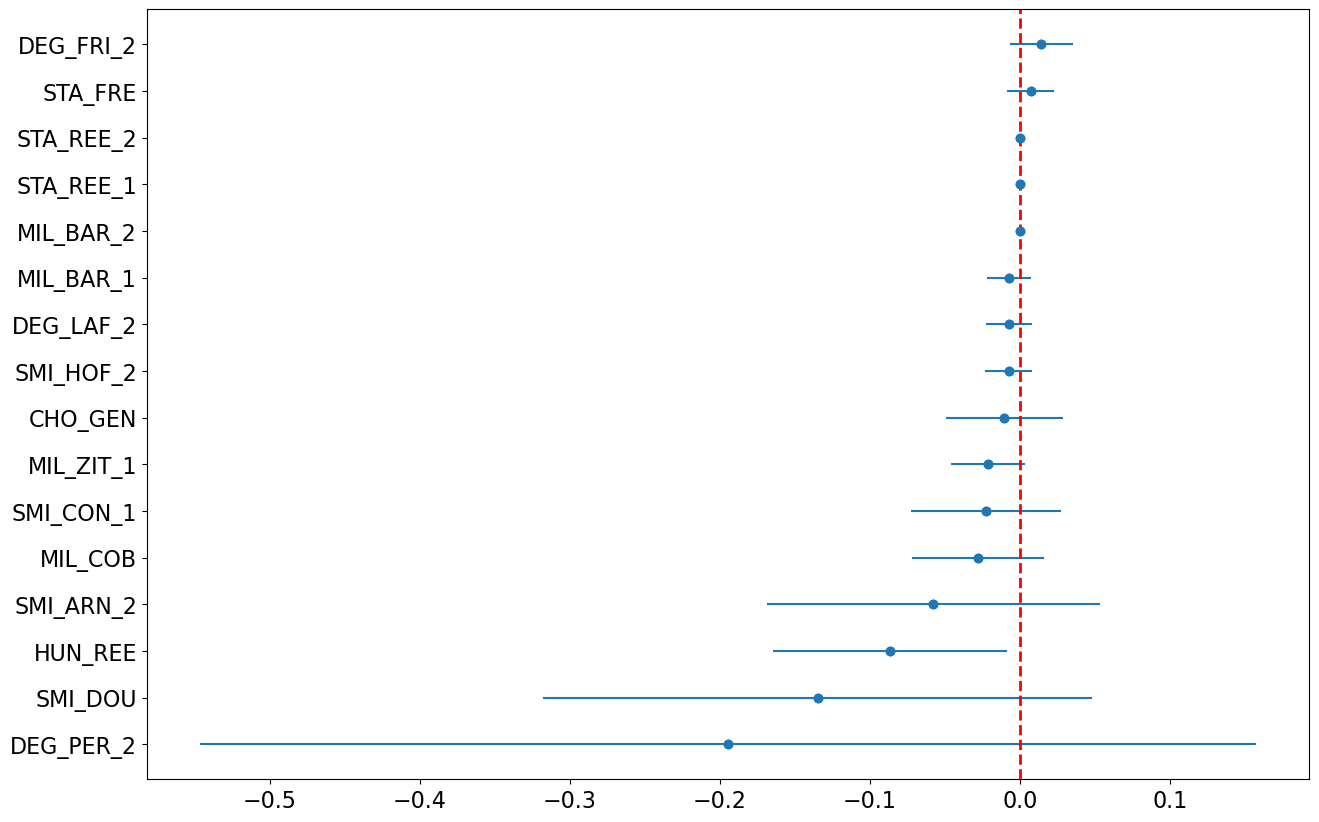

In [24]:
plt.figure(figsize=(15,10))
plt.rcParams.update({'font.size': 16})

plt.scatter(soy_deli_cup_pivot['Diff'], soy_deli_cup_pivot['Field ID'])
plt.errorbar(soy_deli_cup_pivot['Diff'], soy_deli_cup_pivot['Field ID'], xerr=soy_deli_cup_pivot['std'], fmt="o")
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
